In [1]:
!pip install -q transformers torch accelerate sentencepiece


In [2]:
# Import Library
# ==========================================================
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)

In [3]:
# ==========================================================
# Cek GPU
# ==========================================================
device = 0 if torch.cuda.is_available() else -1

if device == 0:
    print("Menggunakan GPU")
else:
    print("Menggunakan CPU")


Menggunakan GPU


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ==========================================================
# Load Dataset
# ==========================================================
df = pd.read_csv("/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/.Process/Clean data/yt_clean.csv")   # ganti sesuai nama file

print(df.head())
print(f"\nJumlah data : {len(df)}")


                                            yt_clean
0  kalo rakyat kompak siapapun anggota dari insti...
1                                           ❤ mantap
2            ahmad syahroni = amit amit jabang bayi.
3  alhamdulillah tamunya satroni buanyak bersilst...
4  waduuh. indonesia kok seperti nepal ya?? tahan...

Jumlah data : 93878


In [6]:
# ==========================================================
# Load Model
# ==========================================================
model_name = "rikidharmawan/finetuning-sentiment-model-indobertweet-v2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

print("\nLabel Model:")
print(model.config.id2label)

pipe = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=device
)

config.json:   0%|          | 0.00/911 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/235k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/738k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  442MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Label Model:
{0: 'Negative', 1: 'Neutral', 2: 'Positive'}


In [7]:
def predict_sentiment(text):

    if pd.isna(text) or str(text).strip() == "":
        return pd.Series(["neutral", 0.0])

    try:
        result = pipe(
            str(text),
            truncation=True,
            max_length=512
        )[0]

        return pd.Series([
            result["label"].lower(),
            float(result["score"])
        ])

    except Exception as e:
        print(e)
        return pd.Series(["error", 0.0])

In [8]:
# ==========================================================
# Prediksi Sentimen
# ==========================================================
df[["label_sentimen","confidence_score"]] = df["yt_clean"].apply(
    predict_sentiment
)

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [9]:
# ==========================================================
# Hasil Awal
# ==========================================================
print(df.head())

                                            yt_clean label_sentimen  \
0  kalo rakyat kompak siapapun anggota dari insti...       negative   
1                                           ❤ mantap       positive   
2            ahmad syahroni = amit amit jabang bayi.       negative   
3  alhamdulillah tamunya satroni buanyak bersilst...        neutral   
4  waduuh. indonesia kok seperti nepal ya?? tahan...       negative   

   confidence_score  
0          0.994756  
1          0.998504  
2          0.943184  
3          0.585058  
4          0.997881  


In [10]:
# ==========================================================
# Statistik Sentimen
# ==========================================================
print("\n==============================")
print("Jumlah Tiap Sentimen")
print("==============================")

print(df["label_sentimen"].value_counts())

print("\nPersentase Sentimen (%)")

print(
    round(
        df["label_sentimen"].value_counts(normalize=True)*100,
        2
    )
)


Jumlah Tiap Sentimen
label_sentimen
negative    61860
neutral     17340
positive    14678
Name: count, dtype: int64

Persentase Sentimen (%)
label_sentimen
negative    65.89
neutral     18.47
positive    15.64
Name: proportion, dtype: float64


In [11]:
# ==========================================================
# Confidence > 0.80
# ==========================================================
high_conf = df[df["confidence_score"] > 0.80]

print("\n==============================")
print("Confidence Score > 0.80")
print("==============================")

print(f"Jumlah : {len(high_conf)}")
print(f"Persentase : {len(high_conf)/len(df)*100:.2f}%")

print("\nPer Sentimen")

print(high_conf["label_sentimen"].value_counts())


Confidence Score > 0.80
Jumlah : 79031
Persentase : 84.18%

Per Sentimen
label_sentimen
negative    55600
neutral     11971
positive    11460
Name: count, dtype: int64


In [12]:
# ==========================================================
# Statistik Confidence
# ==========================================================
print("\n==============================")
print("Statistik Confidence Score")
print("==============================")

print(df["confidence_score"].describe())


Statistik Confidence Score
count    93878.000000
mean         0.917651
std          0.133064
min          0.000000
25%          0.907761
50%          0.985470
75%          0.995496
max          0.999285
Name: confidence_score, dtype: float64


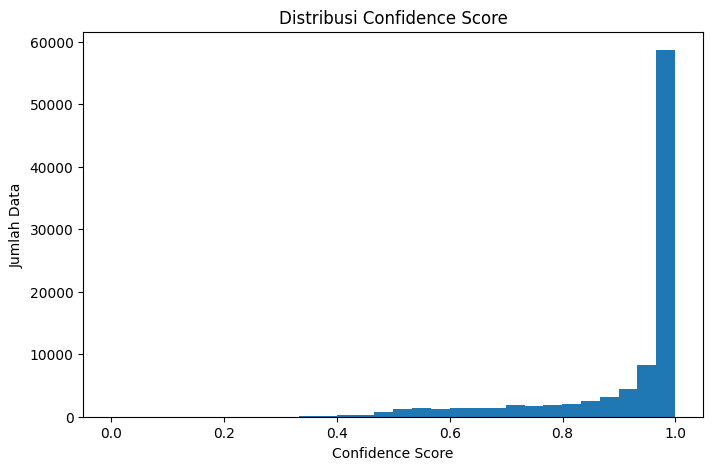

In [13]:
# ==========================================================
# Histogram Confidence
# ==========================================================
plt.figure(figsize=(8,5))

plt.hist(df["confidence_score"], bins=30)

plt.xlabel("Confidence Score")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Confidence Score")

plt.show()

In [14]:
# ==========================================================
# Simpan Hasil
# ==========================================================
output_file = "/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/Youtube/yt_pseudo.csv"

df.to_csv(output_file, index=False)

print(f"\nHasil disimpan di : {output_file}")


Hasil disimpan di : /content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/Youtube/yt_pseudo.csv
